# Imports

In [1]:
import spacy
import pandas as pd
from collections import defaultdict
from tqdm import tqdm  # Correct import
import gender_guesser.detector as gender

df = pd.read_csv('../../Data/2. IntermediateData/df_binarized_hard.csv')

# Testing on 1000 rows

In [9]:
# Initialize spaCy with optimizations
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Take first 1000 rows with original index
sample_df = df.iloc[:1000].copy()

def analyze_with_progress(df_chunk):
    """Process DataFrame chunk with tqdm"""
    results = []
    # Create tqdm iterator explicitly
    tqdm_iterator = tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing dialogues")
    
    for _, row in tqdm_iterator:
        doc = nlp(row["text"])
        subjects = objects = 0
        
        for token in doc:
            # Female reference check
            is_female = (
                token.text.lower() in {"she", "her", "hers", "woman", "girl" } or
                (token.text.lower() == "i" and row["gender"] == "f")
            )
            
            if is_female:
                if token.dep_ in ("nsubj", "nsubjpass"):
                    subjects += 1
                elif token.dep_ in ("dobj", "iobj", "pobj"):
                    objects += 1
        
        results.append({"female_subjects": subjects, "female_objects": objects})
    
    return pd.DataFrame(results)

# Process with progress bar
print("🔍 Analyzing gender references in dialogues...")
result_df = analyze_with_progress(sample_df)

# Combine results
sample_df = pd.concat([sample_df, result_df], axis=1)

# Display results
print("\n📊 Results:")
print(f"Total female subjects: {sample_df['female_subjects'].sum()}")
print(f"Total female objects: {sample_df['female_objects'].sum()}\n")

print("By gender category:")
print(sample_df.groupby("gender")[["female_subjects", "female_objects"]].sum())

print("\n✅ Analysis complete!")

🔍 Analyzing gender references in dialogues...


Analyzing dialogues: 100%|██████████| 1000/1000 [00:01<00:00, 513.56it/s]



📊 Results:
Total female subjects: 199
Total female objects: 37

By gender category:
        female_subjects  female_objects
gender                                 
f                   166               3
m                    33              34

✅ Analysis complete!


In [10]:
sample_df

,utterance_id,conversation_id,text,speaker,movie_id,reply_to,speaker_id,character_name,movie_id.1,title,...,id,imdbid,bechdel_score,imdb_score,numVotes,runtimeMinutes,genres,oscar,female_subjects,female_objects
0,L1045,L1044,They do not!,u0,m0,L1044,u0,BIANCA,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,0,0
1,L1044,L1044,They do to!,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,0,0
2,L985,L984,I hope so.,u0,m0,L984,u0,BIANCA,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,1,0
3,L984,L984,She okay?,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,1,0
4,L925,L924,Let's go.,u0,m0,L924,u0,BIANCA,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,L5084,L5083,You stay with me...,u67,m4,L5083,u67,CATES,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0
996,L5083,L5083,Bullshit. Then i'm staying with the money.,u71,m4,NaN,u71,HAMMOND,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0
997,L5077,L5076,Right. if you ever switch from armed robbery t...,u67,m4,L5076,u67,CATES,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0
998,L5076,L5076,"That was in style a couple years back, man.",u71,m4,NaN,u71,HAMMOND,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0


# Running on whole dataset

In [13]:
import spacy
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

# Initialize spaCy with optimizations
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# ===== EXPANDED GENDERED REFERENCES DICTIONARY =====
GENDERED_TERMS = {
    # Female references
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", "females", "mother", "daughter", "sister", "actress"}
    },
    # Male references
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male", "males", "father", "son", "brother", "actor"}
    },
    # Neutral/inclusive references
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual", "actor", "doctor"}  # Gender-neutral professional terms
    }
}

# Take first 1000 rows for demonstration (replace with full_df for complete analysis)
sample_df = df.copy()

def analyze_with_progress(df_chunk):
    """Process DataFrame with expanded gender analysis"""
    results = []
    tqdm_iterator = tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing dialogues")
    
    for _, row in tqdm_iterator:
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            # Check all gender categories
            for gender_category, terms in GENDERED_TERMS.items():
                # Check pronouns and nouns
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):  # Handle "I" based on speaker gender
                    
                    # Subject/object analysis
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
        
        results.append(counts)
    
    return pd.DataFrame(results)

# Process with progress bar
print("🔍 Analyzing expanded gender references...")
result_df = analyze_with_progress(sample_df)

# Combine results (fill NaN with 0 for missing categories)
sample_df = pd.concat([sample_df, result_df.fillna(0)], axis=1)

# Display results
print("\n📊 Results by Gender Category:")
gender_categories = ["female", "male", "neutral"]
for category in gender_categories:
    print(f"\n{category.capitalize()} References:")
    print(f"Subjects: {sample_df[f'{category}_subjects'].sum():>6}")
    print(f"Objects:  {sample_df[f'{category}_objects'].sum():>6}")

print("\n📈 Subject/Object Ratios:")
for category in gender_categories:
    total = sample_df[[f'{category}_subjects', f'{category}_objects']].sum().sum()
    if total > 0:
        ratio = sample_df[f'{category}_subjects'].sum() / total
        print(f"{category.capitalize()}: {ratio:.1%} subject references")

print("\n✅ Analysis complete!")

🔍 Analyzing expanded gender references...


Analyzing dialogues: 100%|██████████| 137062/137062 [04:58<00:00, 459.80it/s]



📊 Results by Gender Category:

Female References:
Subjects: 29025.0
Objects:  3743.0

Male References:
Subjects: 55602.0
Objects:  5942.0

Neutral References:
Subjects: 8607.0
Objects:  3533.0

📈 Subject/Object Ratios:
Female: 88.6% subject references
Male: 90.3% subject references
Neutral: 70.9% subject references

✅ Analysis complete!


In [18]:
import scipy.stats as stats
import numpy as np
from statsmodels.stats.proportion import proportions_ztest  # Correct import

# Your results
counts = np.array([29025, 55602])    # Female and male subjects
nobs = np.array([29025+3743, 55602+5942])  # Total references per gender

# 1. Two-proportion z-test
z_score, p_value = proportions_ztest(counts, nobs)
print(f"Female vs Male Subject Ratios:")
print(f"Z = {z_score:.2f}, p = {p_value:.20f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

# 2. Effect size (Cohen's h)
female_ratio = counts[0]/nobs[0]
male_ratio = counts[1]/nobs[1]
h = 2*(np.arcsin(np.sqrt(female_ratio)) - np.arcsin(np.sqrt(male_ratio)))
print(f"Effect Size (Cohen's h): {abs(h):.3f}")

# 3. Install statsmodels if needed
try:
    from statsmodels.stats.proportion import proportions_ztest
except ImportError:
    print("\nInstalling required package...")
    import sys
    !{sys.executable} -m pip install statsmodels
    from statsmodels.stats.proportion import proportions_ztest

Female vs Male Subject Ratios:
Z = -8.52, p = 0.00000000000000001650 ***
Effect Size (Cohen's h): 0.058


In [14]:
sample_df

,utterance_id,conversation_id,text,speaker,movie_id,reply_to,speaker_id,character_name,movie_id.1,title,...,numVotes,runtimeMinutes,genres,oscar,neutral_subjects,female_subjects,male_subjects,male_objects,neutral_objects,female_objects
0,L1045,L1044,They do not!,u0,m0,L1044,u0,BIANCA,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,1.0,0.0,0.0,0.0,0.0,0.0
1,L1044,L1044,They do to!,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,1.0,0.0,0.0,0.0,0.0,0.0
2,L985,L984,I hope so.,u0,m0,L984,u0,BIANCA,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,0.0,1.0,0.0,0.0,0.0,0.0
3,L984,L984,She okay?,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,0.0,1.0,0.0,0.0,0.0,0.0
4,L925,L924,Let's go.,u0,m0,L924,u0,BIANCA,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137057,L665991,L665987,"I'm sorry, sir. We only seat by reservation.",u9021,m615,L665990,u9021,MAITRE D',m615,young frankenstein,...,176404,106,Comedy,0,0.0,1.0,0.0,0.0,0.0,0.0
137058,L665990,L665987,Food!!,u9023,m615,L665989,u9023,MONSTER,m615,young frankenstein,...,176404,106,Comedy,0,0.0,0.0,0.0,0.0,0.0,0.0
137059,L665989,L665987,Do you have a reservation?,u9021,m615,L665988,u9021,MAITRE D',m615,young frankenstein,...,176404,106,Comedy,0,0.0,0.0,0.0,0.0,0.0,0.0
137060,L665988,L665987,Food!,u9023,m615,L665987,u9023,MONSTER,m615,young frankenstein,...,176404,106,Comedy,0,0.0,0.0,0.0,0.0,0.0,0.0


# Split by Bechdel Test (binarized)

In [ ]:
# Initialize gender detector
gender_detector = gender.Detector()

# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Gendered references dictionary (without neutral)
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    }
}

# Split dataset
bechdel_1 = df[df['bechdel_score'] == 1].copy()
bechdel_0 = df[df['bechdel_score'] == 0].copy()

def get_gender_from_name(name):
    """Get gender from name using gender_guesser"""
    result = gender_detector.get_gender(name)
    # Only return male/female, ignore other categories
    if result == 'male' or result == 'mostly_male':
        return 'male'
    elif result == 'female' or result == 'mostly_female':
        return 'female'
    return None

def analyze_dataset(df_chunk):
    """Process DataFrame with gender analysis"""
    results = []
    for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing"):
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            # Check for gendered terms from dictionary
            for gender_category, terms in GENDERED_TERMS.items():
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):
                    
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
            
            # Check for names (proper nouns)
            if token.pos_ == "PROPN":
                name_gender = get_gender_from_name(token.text)
                if name_gender:  # Only count if we got male/female
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{name_gender}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{name_gender}_objects"] += 1
        
        results.append(counts)
    return pd.concat([df_chunk, pd.DataFrame(results).fillna(0)], axis=1)

# Analyze both datasets
print("🔍 Analyzing Bechdel-passing films (score=1)...")
bechdel_1 = analyze_dataset(bechdel_1)

print("\n🔍 Analyzing non-Bechdel-passing films (score=0)...")
bechdel_0 = analyze_dataset(bechdel_0)

🔍 Analyzing Bechdel-passing films (score=1)...


Analyzing: 100%|██████████| 69402/69402 [01:54<00:00, 603.85it/s]



🔍 Analyzing non-Bechdel-passing films (score=0)...


Analyzing: 100%|██████████| 67660/67660 [01:54<00:00, 593.49it/s]


In [10]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Statistical comparison function (modified for your case)
def compare_results(df1, df2, category):
    """Compare subject ratios between two datasets"""
    subj1 = df1[f"{category}_subjects"].sum()
    obj1 = df1[f"{category}_objects"].sum()
    subj2 = df2[f"{category}_subjects"].sum()
    obj2 = df2[f"{category}_objects"].sum()
    
    ratio1 = subj1/(subj1+obj1) if (subj1+obj1) > 0 else 0
    ratio2 = subj2/(subj2+obj2) if (subj2+obj2) > 0 else 0
    
    # Perform z-test for proportions
    z, p = proportions_ztest(
        [subj1, subj2],  # Number of successes (subjects)
        [subj1+obj1, subj2+obj2]  # Total trials
    )
    
    # Calculate effect size (Cohen's h)
    h = 2*(np.arcsin(np.sqrt(ratio1)) - np.arcsin(np.sqrt(ratio2)))
    
    print(f"\n{category.upper()} COMPARISON:")
    print(f"Bechdel 1: {ratio1:.1%} subjects ({subj1:,}/{subj1+obj1:,})")
    print(f"Bechdel 0: {ratio2:.1%} subjects ({subj2:,}/{subj2+obj2:,})")
    print(f"Difference: {ratio1-ratio2:+.2%} points")
    print(f"Z = {z:.2f}, p = {p:.4f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}")
    print(f"Effect size (h): {abs(h):.3f} {'(small)' if abs(h) < 0.2 else '(medium)' if abs(h) < 0.5 else '(large)'}")

# Display basic results
print("\n📊 BECHDEL 1 RESULTS (PASSING FILMS):")
for category in ['female', 'male']:
    total = bechdel_1[f"{category}_subjects"].sum() + bechdel_1[f"{category}_objects"].sum()
    ratio = bechdel_1[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize():6}: Subjects={bechdel_1[f'{category}_subjects'].sum():6,} | Objects={bechdel_1[f'{category}_objects'].sum():6,} | Subject Ratio={ratio:.1%}")

print("\n📊 BECHDEL 0 RESULTS (NON-PASSING FILMS):")
for category in ['female', 'male']:
    total = bechdel_0[f"{category}_subjects"].sum() + bechdel_0[f"{category}_objects"].sum()
    ratio = bechdel_0[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize():6}: Subjects={bechdel_0[f'{category}_subjects'].sum():6,} | Objects={bechdel_0[f'{category}_objects'].sum():6,} | Subject Ratio={ratio:.1%}")

# Perform statistical comparisons
print("\n🔍 STATISTICAL COMPARISONS")
for category in ['female', 'male']:
    compare_results(bechdel_1, bechdel_0, category)

# Additional analysis: Female subject ratio distribution
print("\n📈 FEMALE SUBJECT RATIO DISTRIBUTION")
print("Bechdel 1 (Passing):")
print(bechdel_1['female_subject_ratio'].describe())
print("\nBechdel 0 (Non-passing):")
print(bechdel_0['female_subject_ratio'].describe())

print("\n✅ Analysis complete!")


📊 BECHDEL 1 RESULTS (PASSING FILMS):
Female: Subjects=19,332.0 | Objects=2,984.0 | Subject Ratio=86.6%
Male  : Subjects=26,857.0 | Objects=4,147.0 | Subject Ratio=86.6%

📊 BECHDEL 0 RESULTS (NON-PASSING FILMS):
Female: Subjects=10,794.0 | Objects=2,068.0 | Subject Ratio=83.9%
Male  : Subjects=31,595.0 | Objects=4,514.0 | Subject Ratio=87.5%

🔍 STATISTICAL COMPARISONS

FEMALE COMPARISON:
Bechdel 1: 86.6% subjects (19,332.0/22,316.0)
Bechdel 0: 83.9% subjects (10,794.0/12,862.0)
Difference: +2.71% points
Z = 6.97, p = 0.0000 ***
Effect size (h): 0.076 (small)

MALE COMPARISON:
Bechdel 1: 86.6% subjects (26,857.0/31,004.0)
Bechdel 0: 87.5% subjects (31,595.0/36,109.0)
Difference: -0.87% points
Z = -3.37, p = 0.0008 ***
Effect size (h): 0.026 (small)

📈 FEMALE SUBJECT RATIO DISTRIBUTION
Bechdel 1 (Passing):
count    103343.000000
mean          0.119692
std           0.321116
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000


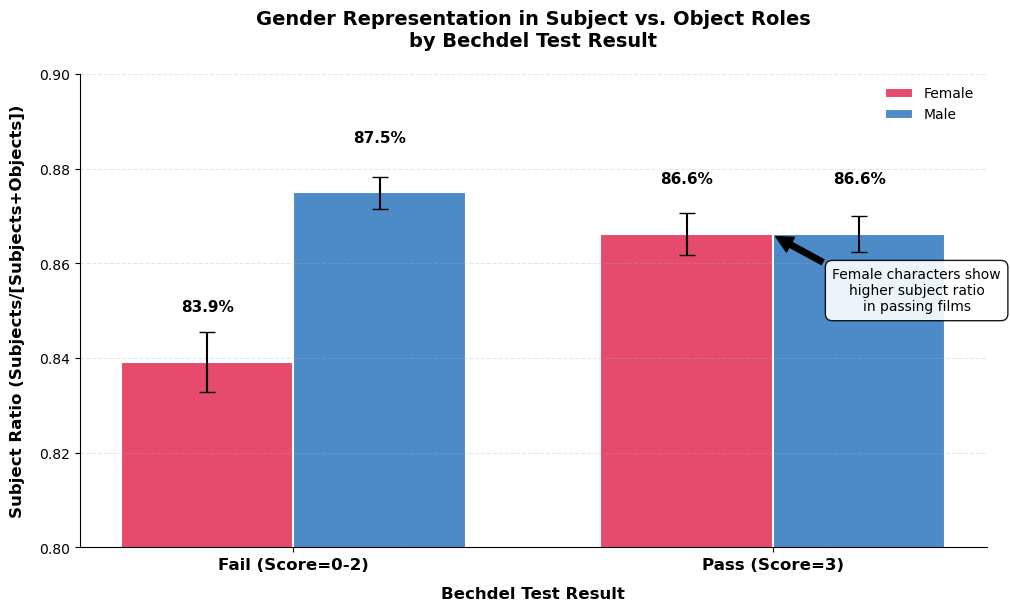

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Create the DataFrame with YOUR actual results
data = {
    'bechdel_score': [0, 0, 1, 1],  # 0 comes first
    'gender': ['female', 'male', 'female', 'male'],
    'subjects': [10794.0, 31595.0, 19332.0, 26857.0],  # Your actual subject counts
    'objects': [2068.0, 4514.0, 2984.0, 4147.0]      # Your actual object counts
}

df = pd.DataFrame(data)

# Calculate ratios and confidence intervals
df['ratio'] = df['subjects'] / (df['subjects'] + df['objects'])
df['ci_low'], df['ci_high'] = proportion_confint(
    count=df['subjects'],
    nobs=df['subjects'] + df['objects'],
    alpha=0.05,
    method='wilson'
)

# Custom styling
plt.rcParams['font.family'] = 'DejaVu Sans'

# Create figure with constrained layout
fig, ax = plt.subplots(figsize=(10, 6), 
                      layout='constrained')

# Color scheme
colors = {'female': '#E64B6D', 'male': '#4D8AC8'}  # More professional palette
bar_width = 0.36  # Optimal width for this layout

# Plot configuration
x_positions = np.array([0, 1])  # For Fail/Pass categories

for i, gender in enumerate(['female', 'male']):
    gender_data = df[df['gender'] == gender]
    offset = (i - 0.5) * bar_width
    
    # Plot bars with error bars
    bars = ax.bar(
        x_positions + offset,
        gender_data['ratio'],
        width=bar_width,
        color=colors[gender],
        label=gender.capitalize(),
        yerr=[
            gender_data['ratio'] - gender_data['ci_low'],
            gender_data['ci_high'] - gender_data['ratio']
        ],
        capsize=6,
        edgecolor='white',
        linewidth=1.5
    )
    
    # Add value labels with contrasting text
    for bar, ratio in zip(bars, gender_data['ratio']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.,
                height + 0.01,
                f'{ratio:.1%}',
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold',
                color='black')

# Axes and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(['Fail (Score=0-2)', 'Pass (Score=3)'], 
                  fontsize=12, 
                  fontweight='semibold')
ax.set_yticks(np.arange(0.80, 0.91, 0.02))
ax.set_ylim(0.80, 0.90)
ax.set_ylabel('Subject Ratio (Subjects/[Subjects+Objects])', 
             fontsize=12,
             fontweight='semibold',
             labelpad=10)
ax.set_xlabel('Bechdel Test Result', 
             fontsize=12,
             fontweight='semibold',
             labelpad=10)

# Title and legend
ax.set_title('Gender Representation in Subject vs. Object Roles\nby Bechdel Test Result',
            fontsize=14,
            fontweight='bold',
            pad=20)
ax.legend(loc='upper right',
          frameon=True,
          framealpha=1,
          edgecolor='white')

# Grid and spines
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Annotate key findings
ax.annotate('Female characters show\nhigher subject ratio\nin passing films',
            xy=(1, 0.866), xytext=(1.3, 0.85),
            arrowprops=dict(facecolor='black', shrink=0.05),
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))

plt.show()

# All Data

In [16]:
df = pd.read_csv('../../Data/2. IntermediateData/df_clean_original.csv')
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import spacy
import gender_guesser.detector as gender
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Initialize gender detector
gender_detector = gender.Detector()

# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Gendered references dictionary
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    }
}

# Split dataset into all 4 categories
bechdel_0 = df[df['bechdel_score'] == 0].copy()
bechdel_1 = df[df['bechdel_score'] == 1].copy()
bechdel_2 = df[df['bechdel_score'] == 2].copy()
bechdel_3 = df[df['bechdel_score'] == 3].copy()

def get_gender_from_name(name):
    """Get gender from name using gender_guesser"""
    result = gender_detector.get_gender(name)
    if result in ['male', 'mostly_male']:
        return 'male'
    elif result in ['female', 'mostly_female']:
        return 'female'
    return None

def analyze_dataset(df_chunk):
    """Process DataFrame with gender analysis"""
    results = []
    for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing"):
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            # Check gendered terms
            for gender_category, terms in GENDERED_TERMS.items():
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):
                    
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
            
            # Check names
            if token.pos_ == "PROPN":
                name_gender = get_gender_from_name(token.text)
                if name_gender:
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{name_gender}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{name_gender}_objects"] += 1
        
        results.append(counts)
    return pd.concat([df_chunk, pd.DataFrame(results).fillna(0)], axis=1)

# Analyze all categories
print("🔍 Analyzing Bechdel score 0 films...")
bechdel_0 = analyze_dataset(bechdel_0)

print("\n🔍 Analyzing Bechdel score 1 films...")
bechdel_1 = analyze_dataset(bechdel_1)

print("\n🔍 Analyzing Bechdel score 2 films...")
bechdel_2 = analyze_dataset(bechdel_2)

print("\n🔍 Analyzing Bechdel score 3 films...")
bechdel_3 = analyze_dataset(bechdel_3)

# Combine all results into one dataframe
all_results = pd.concat([bechdel_0, bechdel_1, bechdel_2, bechdel_3])

# Create summary dataframe
summary_data = []
for score in [0, 1, 2, 3]:
    df_score = all_results[all_results['bechdel_score'] == score]
    for gender in ['female', 'male']:
        subjects = df_score[f'{gender}_subjects'].sum()
        objects = df_score[f'{gender}_objects'].sum()
        total = subjects + objects
        ratio = subjects / total if total > 0 else 0
        
        # Calculate confidence intervals
        ci_low, ci_high = proportion_confint(subjects, total, alpha=0.05, method='wilson')
        
        summary_data.append({
            'bechdel_score': score,
            'gender': gender,
            'subjects': subjects,
            'objects': objects,
            'subject_ratio': ratio,
            'ci_low': ci_low,
            'ci_high': ci_high
        })

summary_df = pd.DataFrame(summary_data)

# Add movie counts per category
movie_counts = all_results['bechdel_score'].value_counts().sort_index()
summary_df['movie_count'] = summary_df['bechdel_score'].map(movie_counts)

# Calculate per-movie averages
summary_df['subjects_per_movie'] = summary_df['subjects'] / summary_df['movie_count']
summary_df['objects_per_movie'] = summary_df['objects'] / summary_df['movie_count']

# Save the results
summary_df.to_csv('gender_role_analysis_by_bechdel_score.csv', index=False)

print("\n✅ Analysis complete! Results saved to CSV.")
print(summary_df[['bechdel_score', 'gender', 'subjects', 'objects', 'subject_ratio', 'movie_count']])

🔍 Analyzing Bechdel score 0 films...


Analyzing: 100%|██████████| 10101/10101 [00:18<00:00, 541.51it/s]



🔍 Analyzing Bechdel score 1 films...


Analyzing: 100%|██████████| 36903/36903 [01:03<00:00, 585.05it/s]



🔍 Analyzing Bechdel score 2 films...


Analyzing: 100%|██████████| 20656/20656 [00:34<00:00, 598.50it/s]



🔍 Analyzing Bechdel score 3 films...


Analyzing: 100%|██████████| 69402/69402 [01:57<00:00, 588.82it/s]



✅ Analysis complete! Results saved to CSV.
   bechdel_score  gender  subjects  objects  subject_ratio  movie_count
0              0  female      14.0      1.0       0.933333        10101
1              0    male      83.0     16.0       0.838384        10101
2              1  female    1462.0    316.0       0.822272        36903
3              1    male    4035.0    620.0       0.866810        36903
4              2  female     592.0     73.0       0.890226        20656
5              2    male    2069.0    335.0       0.860649        20656
6              3  female    9504.0   1560.0       0.859002        69402
7              3    male   13713.0   2018.0       0.871718        69402
